In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score, root_mean_squared_error

In [12]:
df = pd.read_csv("solar panels dataset final.csv")

# Preview the data
print(df.head())
print(df.shape)

         date  Solar Electricity Net Generation (Megawattshour)  \
0  01/01/2015                                          1901.796   
1  01/02/2015                                          2299.318   
2  01/03/2015                                          3205.834   
3  01/04/2015                                          3642.646   
4  01/05/2015                                          3897.986   

   Temperature F  Temperature C  Precipitation  co2 emissions      date.1  \
0      31.150816      -0.471769       2.092245    5368.496582  01/01/2015   
1      29.458061      -1.412188       1.885408    5368.496582  01/02/2015   
2      43.121327       6.178515       2.425000    5368.496582  01/03/2015   
3      52.713469      11.507483       3.156327    5368.496582  01/04/2015   
4      61.488980      16.382766       4.232143    5368.496582  01/05/2015   

   kwh_price   savings  investment  Montly Total ETR (millions USD)  \
0   9.420968  0.000000      1.0948                          699

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 20 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   date                                              120 non-null    str    
 1   Solar Electricity Net Generation (Megawattshour)  120 non-null    float64
 2   Temperature F                                     120 non-null    float64
 3   Temperature C                                     120 non-null    float64
 4   Precipitation                                     120 non-null    float64
 5   co2 emissions                                     120 non-null    float64
 6   date.1                                            120 non-null    str    
 7   kwh_price                                         120 non-null    float64
 8   savings                                           120 non-null    float64
 9   investment                      

# 1. Data preprocessing

In [14]:
df_a = df.drop(columns= "date.1")
df_a.head()

,date,Solar Electricity Net Generation (Megawattshour),Temperature F,Temperature C,Precipitation,co2 emissions,kwh_price,savings,investment,Montly Total ETR (millions USD),Environmental Tax Revenue Percentage of GDP (%),ITC Investment Tax Credit %,Green Growth coefficient,Executive Party Democratic,Executive Party Republican,Legislative House Majority Democratic,Legislative House Majority Republican,Senate Majority Democratic,Senate Majority Republican
0,01/01/2015,1901.796,31.150816,-0.471769,2.092245,5368.496582,9.420968,0.000000,1.0948,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1
1,01/02/2015,2299.318,29.458061,-1.412188,1.885408,5368.496582,9.600040,0.218902,0.3128,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1
2,01/03/2015,3205.834,43.121327,6.178515,2.425000,5368.496582,9.576734,-0.213650,0.0782,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1
3,01/04/2015,3642.646,52.713469,11.507483,3.156327,5368.496582,9.502137,-0.099786,0.1173,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1
4,01/05/2015,3897.986,61.488980,16.382766,4.232143,5368.496582,9.625282,-0.296312,0.5083,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1


In [15]:
df_a["date"] = pd.to_datetime(df_a["date"], format= "%d/%m/%Y")
df_a.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 19 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   date                                              120 non-null    datetime64[us]
 1   Solar Electricity Net Generation (Megawattshour)  120 non-null    float64       
 2   Temperature F                                     120 non-null    float64       
 3   Temperature C                                     120 non-null    float64       
 4   Precipitation                                     120 non-null    float64       
 5   co2 emissions                                     120 non-null    float64       
 6   kwh_price                                         120 non-null    float64       
 7   savings                                           120 non-null    float64       
 8   investment                               

In [16]:
df_b = df_a.set_index('date')

In [19]:
df_b.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 120 entries, 2015-01-01 to 2024-12-01
Data columns (total 18 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Solar Electricity Net Generation (Megawattshour)  120 non-null    float64
 1   Temperature F                                     120 non-null    float64
 2   Temperature C                                     120 non-null    float64
 3   Precipitation                                     120 non-null    float64
 4   co2 emissions                                     120 non-null    float64
 5   kwh_price                                         120 non-null    float64
 6   savings                                           120 non-null    float64
 7   investment                                        120 non-null    float64
 8   Montly Total ETR (millions USD)                   120 non-null    float64
 9   Environmental

In [20]:
df_b.head()

,Solar Electricity Net Generation (Megawattshour),Temperature F,Temperature C,Precipitation,co2 emissions,kwh_price,savings,investment,Montly Total ETR (millions USD),Environmental Tax Revenue Percentage of GDP (%),ITC Investment Tax Credit %,Green Growth coefficient,Executive Party Democratic,Executive Party Republican,Legislative House Majority Democratic,Legislative House Majority Republican,Senate Majority Democratic,Senate Majority Republican
date,,,,,,,,,,,,,,,,,,
2015-01-01,1901.796,31.150816,-0.471769,2.092245,5368.496582,9.420968,0.000000,1.0948,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1
2015-02-01,2299.318,29.458061,-1.412188,1.885408,5368.496582,9.600040,0.218902,0.3128,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1
2015-03-01,3205.834,43.121327,6.178515,2.425000,5368.496582,9.576734,-0.213650,0.0782,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1
2015-04-01,3642.646,52.713469,11.507483,3.156327,5368.496582,9.502137,-0.099786,0.1173,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1
2015-05-01,3897.986,61.488980,16.382766,4.232143,5368.496582,9.625282,-0.296312,0.5083,6995.95,0.458876,0.3,4.02,1,0,0,1,0,1


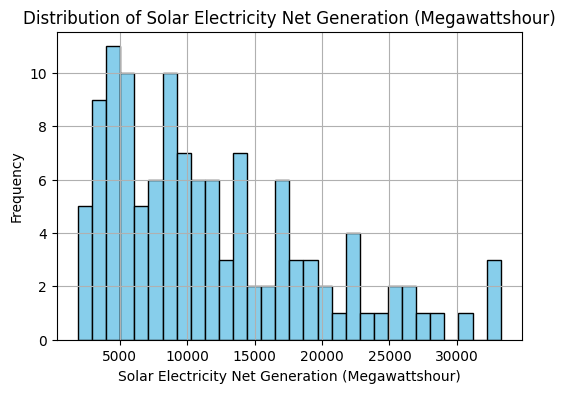

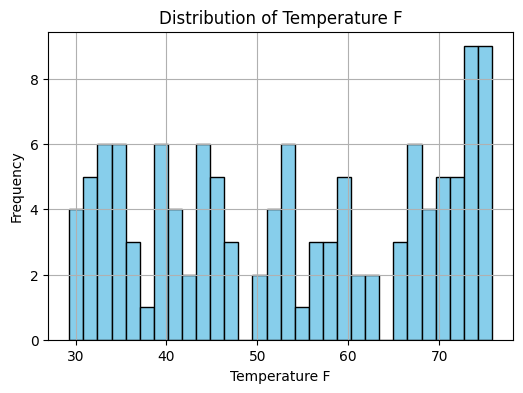

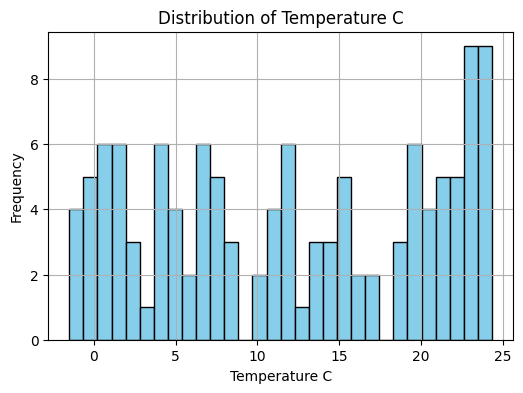

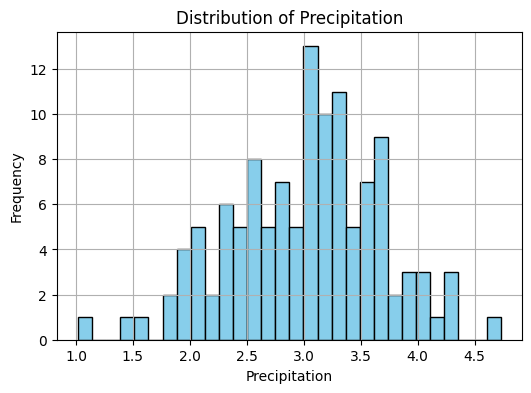

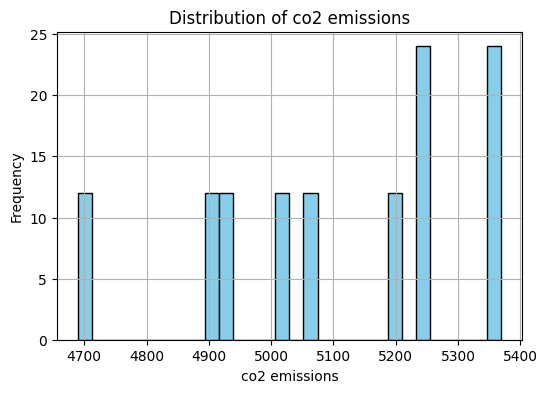

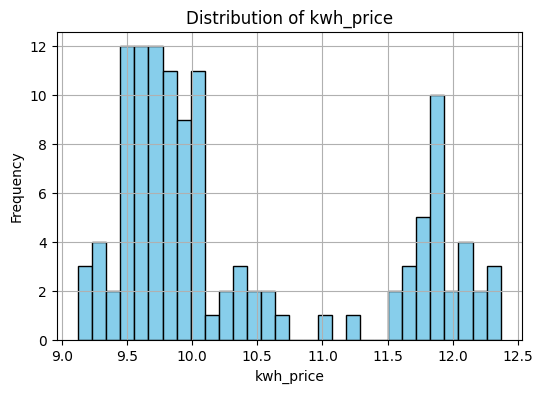

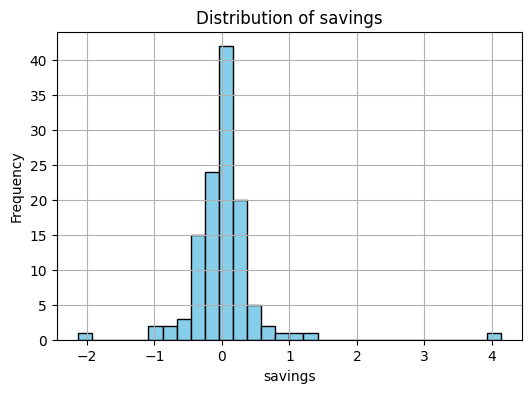

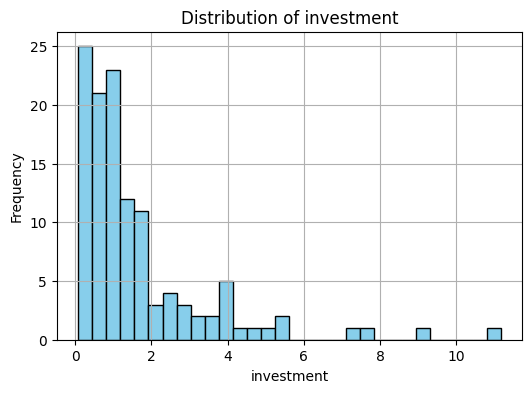

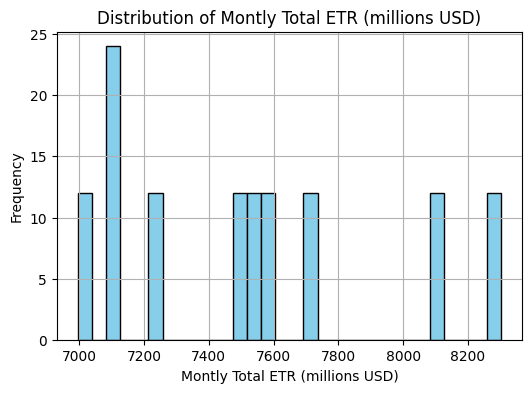

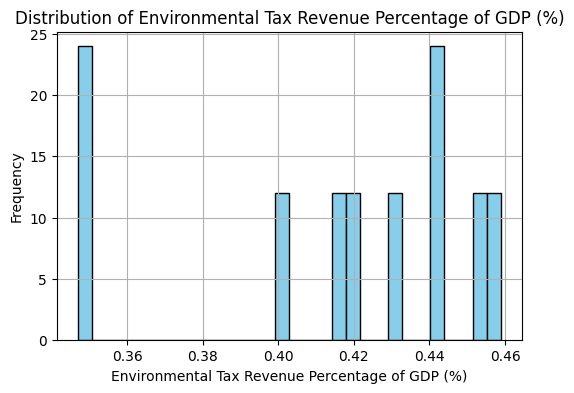

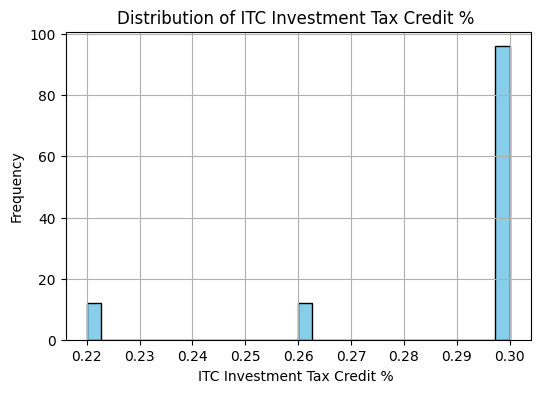

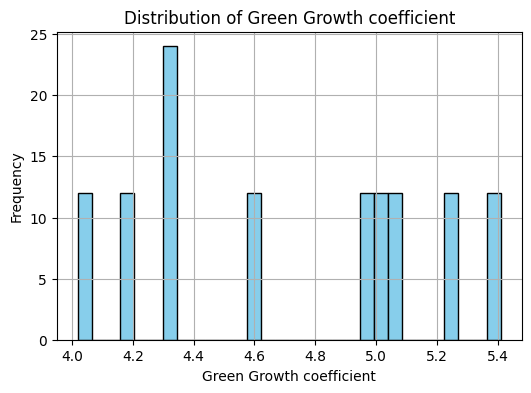

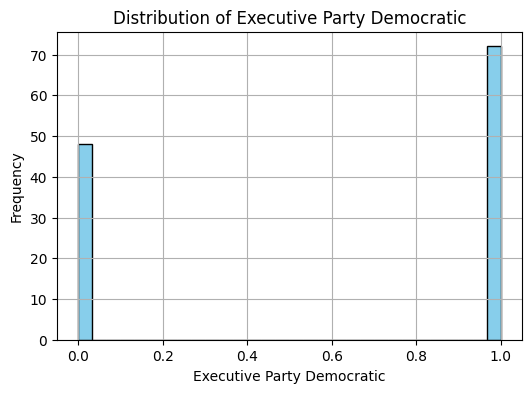

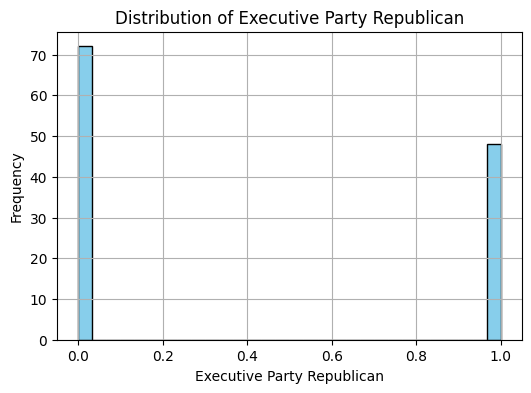

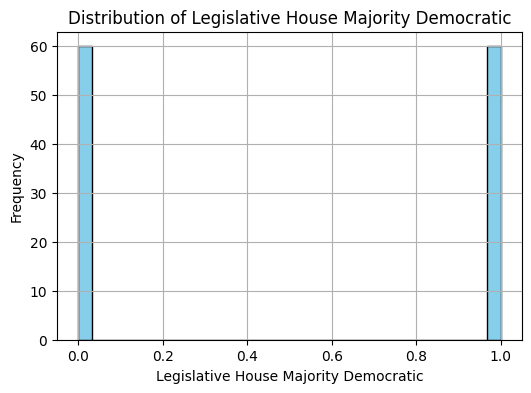

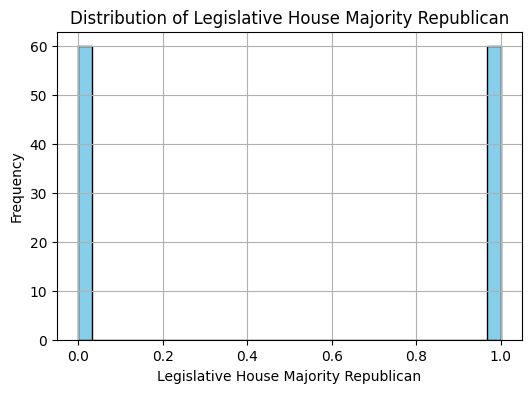

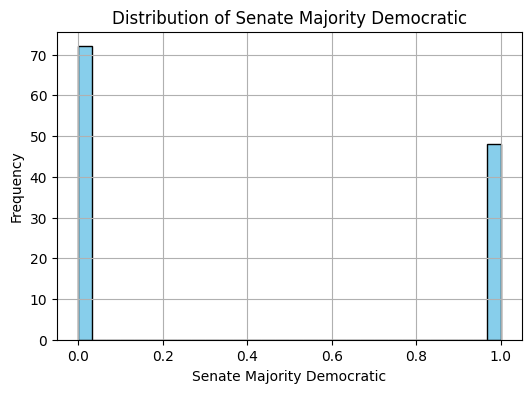

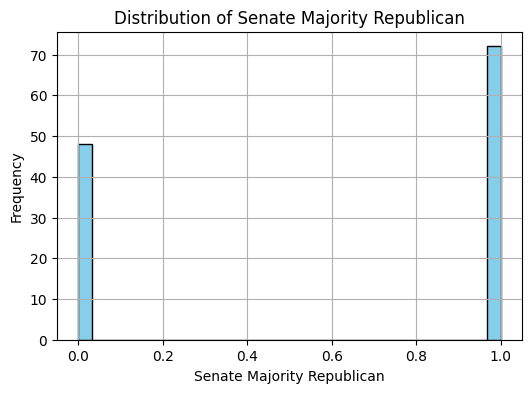

In [21]:
cols_num = df_b.select_dtypes(include= "number")

for col in cols_num:
    plt.figure(figsize=(6,4))
    plt.hist(df_b[col], bins= 30, color= 'skyblue', edgecolor= 'black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

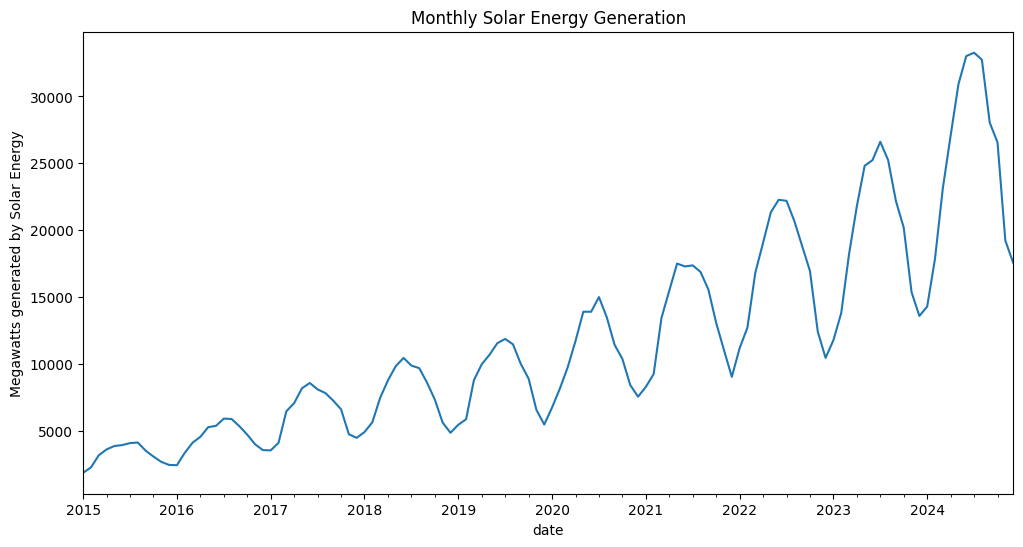

In [22]:
df_b['Solar Electricity Net Generation (Megawattshour)'].plot(figsize=(12, 6), title='Monthly Solar Energy Generation')
plt.ylabel('Megawatts generated by Solar Energy')
plt.show()

In [23]:
outlier_indices = dict()

for col in cols_num:
    skewness = df_b[col].skew()
    print(f"\nColumn: {col:<15} skewness = {skewness:.2f}")
    
    if abs(skewness) < 0.5:
        # approximately normal → Z-score method
        zscores = np.abs(stats.zscore(df_b[col]))
        mask = zscores > 3
        method = '|Z-score| > 3'
    else:
        # skewed → IQR method
        Q1 = df_b[col].quantile(0.25)
        Q3 = df_b[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        mask = (df_b[col] < lower) | (df_b[col] > upper)
        method = 'IQR 1.5× range'
    
    idx = df_b[mask].index
    outlier_indices[col] = idx
    print(f"  Detected {len(idx)} outliers by {method}.")


Column: Solar Electricity Net Generation (Megawattshour) skewness = 0.98
  Detected 0 outliers by IQR 1.5× range.

Column: Temperature F   skewness = -0.03
  Detected 0 outliers by |Z-score| > 3.

Column: Temperature C   skewness = -0.03
  Detected 0 outliers by |Z-score| > 3.

Column: Precipitation   skewness = -0.21
  Detected 0 outliers by |Z-score| > 3.

Column: co2 emissions   skewness = -0.43
  Detected 0 outliers by |Z-score| > 3.

Column: kwh_price       skewness = 0.84
  Detected 0 outliers by IQR 1.5× range.

Column: savings         skewness = 3.17
  Detected 7 outliers by IQR 1.5× range.

Column: investment      skewness = 2.59
  Detected 14 outliers by IQR 1.5× range.

Column: Montly Total ETR (millions USD) skewness = 0.54
  Detected 0 outliers by IQR 1.5× range.

Column: Environmental Tax Revenue Percentage of GDP (%) skewness = -0.85
  Detected 0 outliers by IQR 1.5× range.

Column: ITC Investment Tax Credit %  skewness = -1.94
  Detected 24 outliers by IQR 1.5× range.


Outliers are not data entry errors and represent real data that will not be modified or eliminated to avoid any misrepresentation of the nature of data

Correlation Matrix:
                                                   Solar Electricity Net Generation (Megawattshour)  \
Solar Electricity Net Generation (Megawattshour)                                          1.000000   
Temperature F                                                                             0.376886   
Temperature C                                                                             0.376886   
Precipitation                                                                             0.009201   
co2 emissions                                                                            -0.594895   
kwh_price                                                                                 0.878962   
savings                                                                                   0.099455   
investment                                                                                0.259812   
Montly Total ETR (millions USD)                              

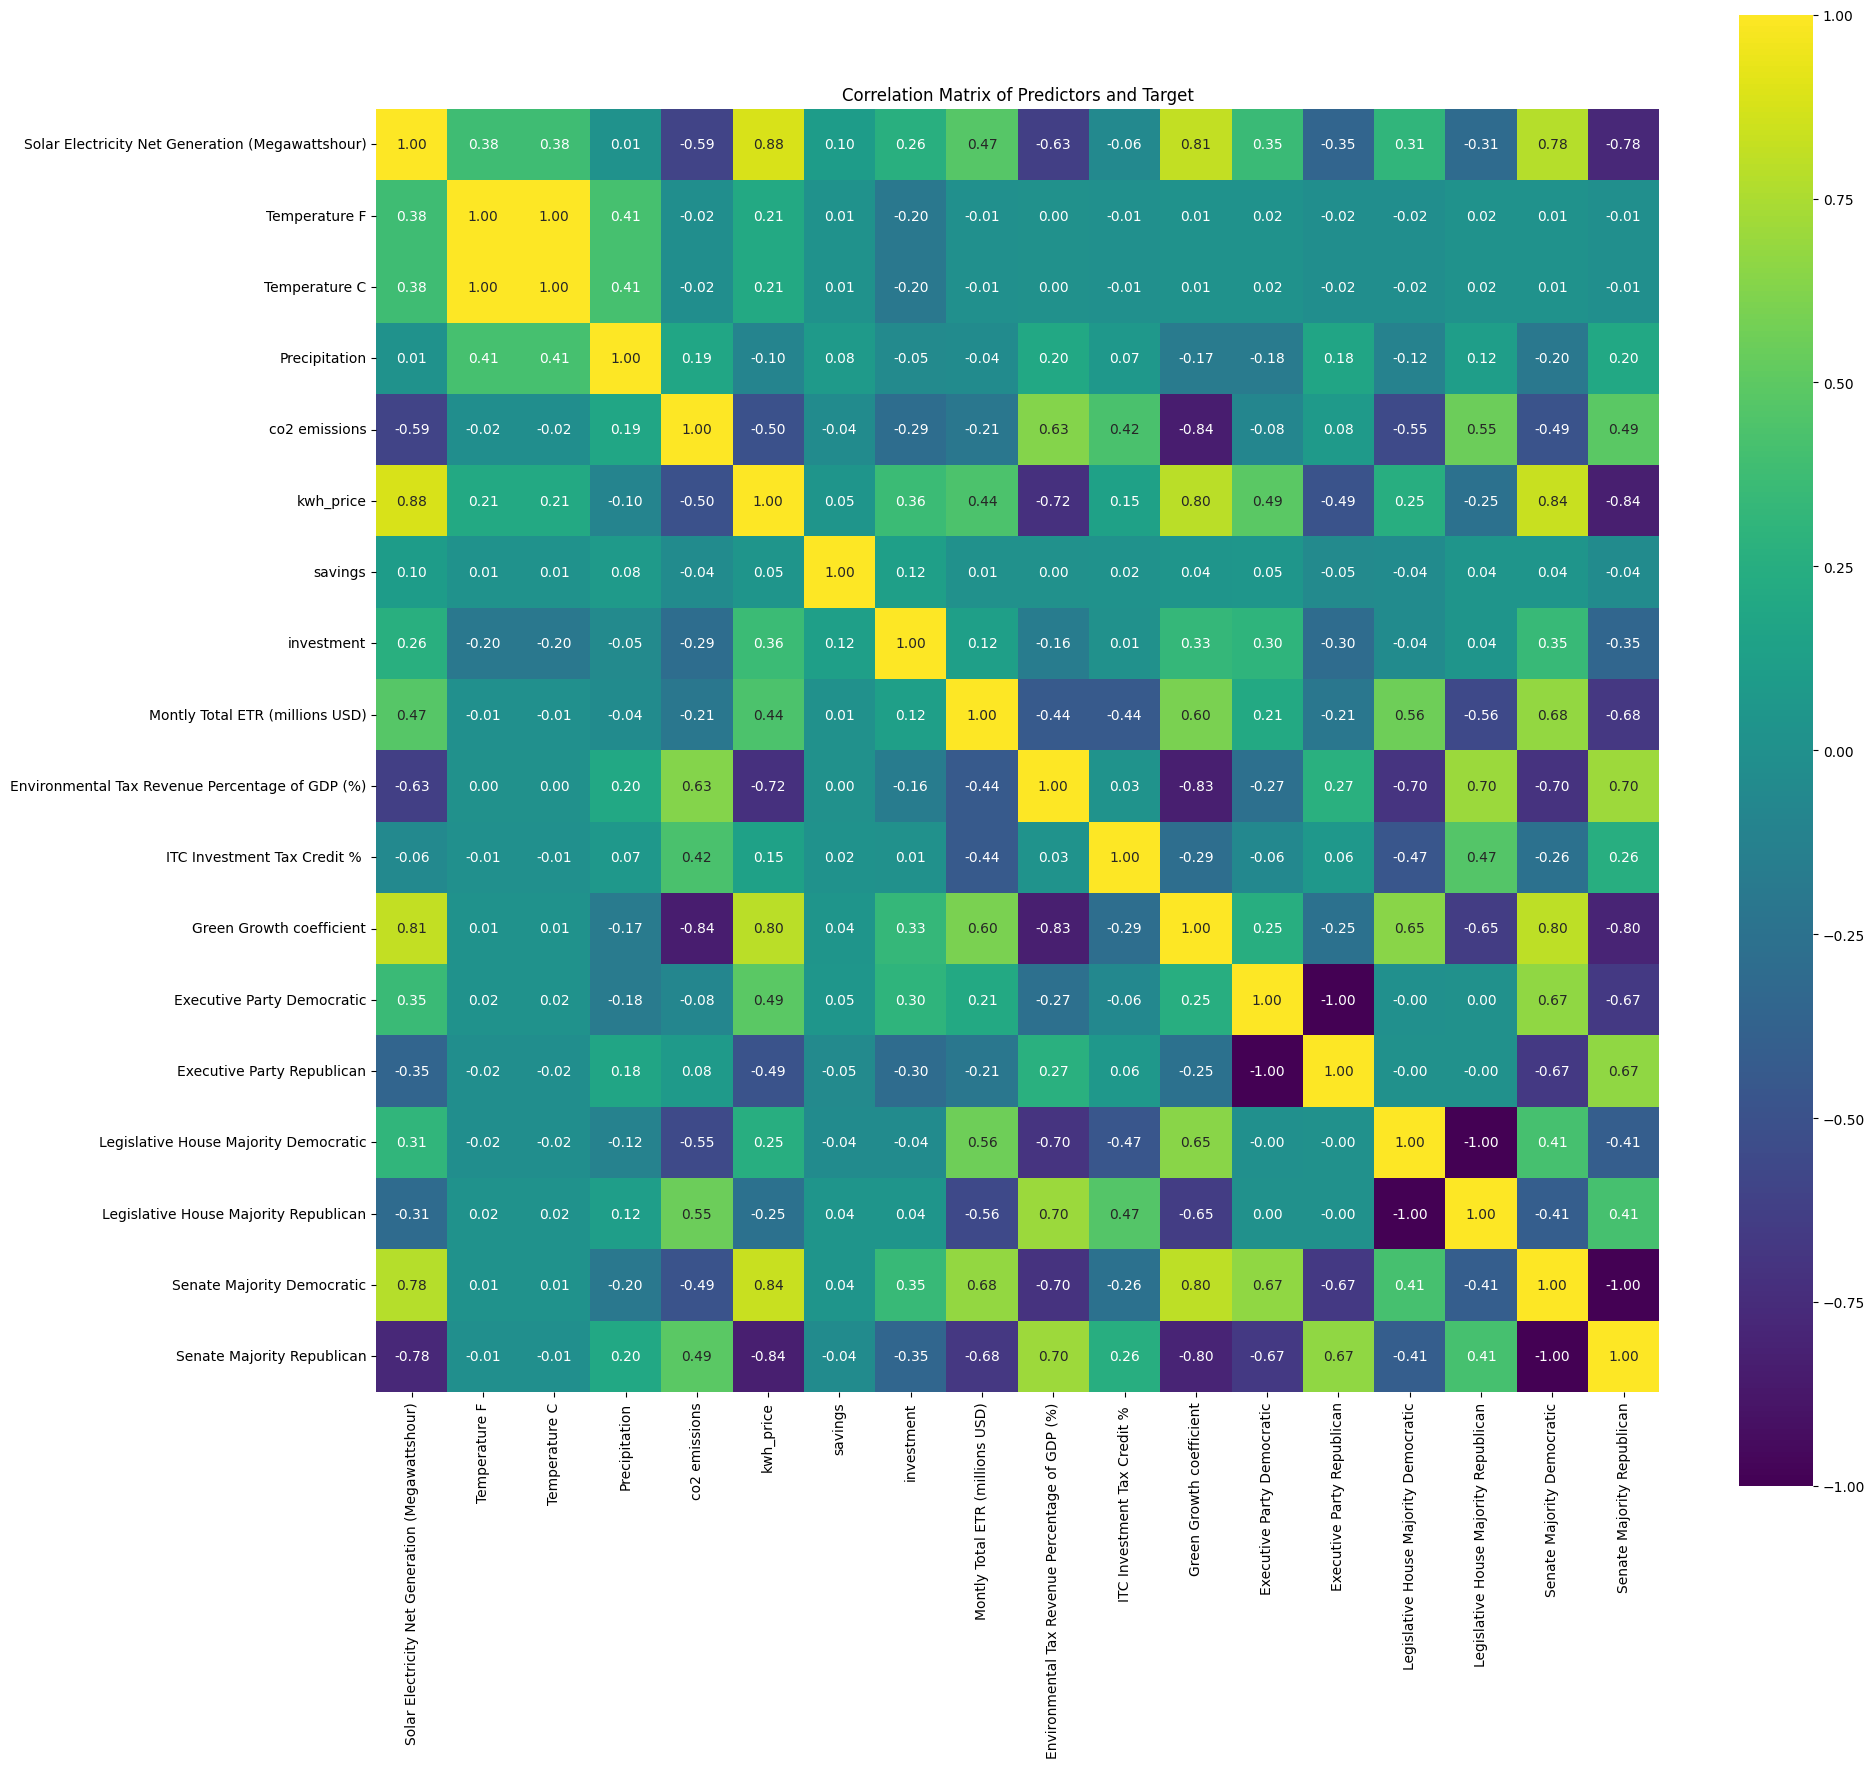

In [32]:
# Display correlation matrix

corr_matrix = df_b.corr()

print("Correlation Matrix:\n", corr_matrix)

# Visualize with a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", square=True)
plt.title("Correlation Matrix of Predictors and Target")
plt.tight_layout()
plt.show()

Let's eliminate the binary columns to confirm multicollinearity of temperature

In [41]:
cols_num_list = cols_num.drop(columns= ['Executive Party Democratic', 'Executive Party Republican',
       'Legislative House Majority Democratic',
       'Legislative House Majority Republican', 'Senate Majority Democratic',
       'Senate Majority Republican']).columns

print(cols_num_list)

Index(['Solar Electricity Net Generation (Megawattshour)', 'Temperature F',
       'Temperature C', 'Precipitation', 'co2 emissions', 'kwh_price',
       'savings', 'investment', 'Montly Total ETR (millions USD)',
       'Environmental Tax Revenue Percentage of GDP (%)',
       'ITC Investment Tax Credit % ', 'Green Growth coefficient'],
      dtype='str')


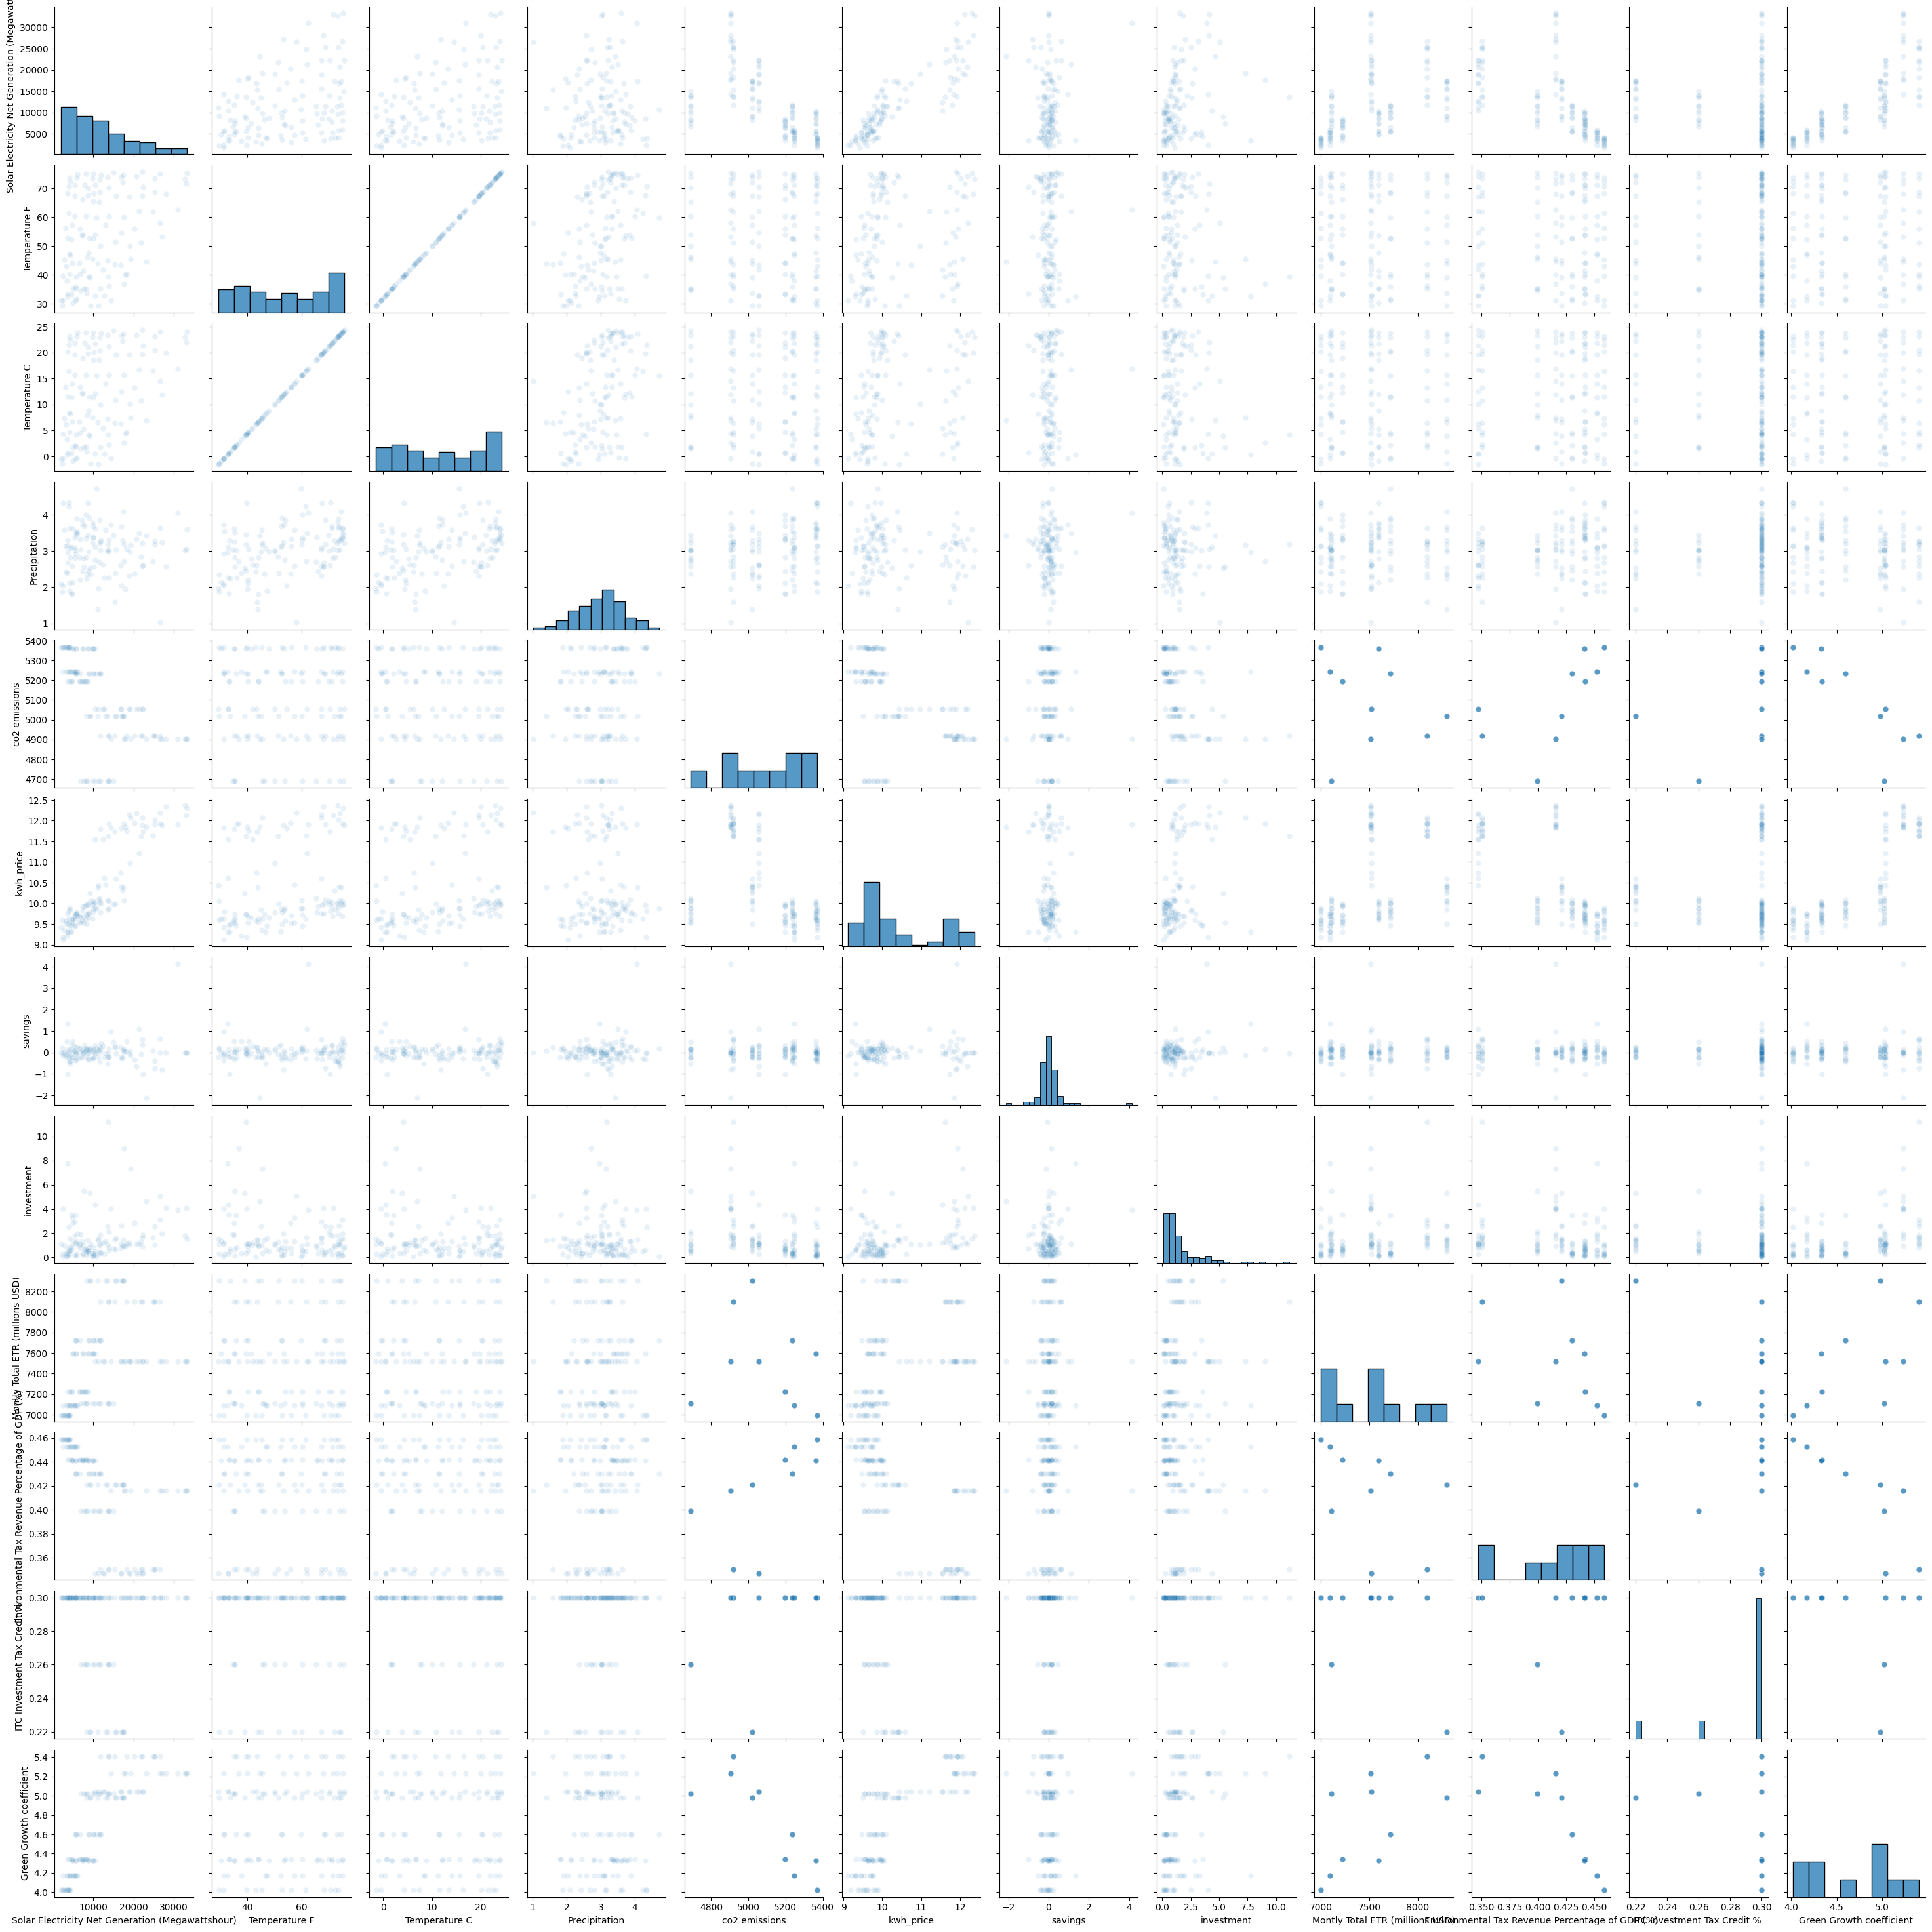

In [42]:
sns.pairplot(df_b[cols_num_list], plot_kws={'alpha': 0.1})

let's select the variables of interest that can become predictors

In [50]:
df_b.columns

df_c = df_b.drop(columns= ['Temperature C', 'Executive Party Republican', 'Legislative House Majority Republican', 'Senate Majority Republican']).reset_index()

df_c.head()

,date,Solar Electricity Net Generation (Megawattshour),Temperature F,Precipitation,co2 emissions,kwh_price,savings,investment,Montly Total ETR (millions USD),Environmental Tax Revenue Percentage of GDP (%),ITC Investment Tax Credit %,Green Growth coefficient,Executive Party Democratic,Legislative House Majority Democratic,Senate Majority Democratic
0,2015-01-01,1901.796,31.150816,2.092245,5368.496582,9.420968,0.000000,1.0948,6995.95,0.458876,0.3,4.02,1,0,0
1,2015-02-01,2299.318,29.458061,1.885408,5368.496582,9.600040,0.218902,0.3128,6995.95,0.458876,0.3,4.02,1,0,0
2,2015-03-01,3205.834,43.121327,2.425000,5368.496582,9.576734,-0.213650,0.0782,6995.95,0.458876,0.3,4.02,1,0,0
3,2015-04-01,3642.646,52.713469,3.156327,5368.496582,9.502137,-0.099786,0.1173,6995.95,0.458876,0.3,4.02,1,0,0
4,2015-05-01,3897.986,61.488980,4.232143,5368.496582,9.625282,-0.296312,0.5083,6995.95,0.458876,0.3,4.02,1,0,0


In [52]:
X = df_c.drop(['Solar Electricity Net Generation (Megawattshour)', "date"], axis = 1)
y = df_c['Solar Electricity Net Generation (Megawattshour)']
print(X)

     Temperature F  Precipitation  co2 emissions  kwh_price   savings  \
0        31.150816       2.092245    5368.496582   9.420968  0.000000   
1        29.458061       1.885408    5368.496582   9.600040  0.218902   
2        43.121327       2.425000    5368.496582   9.576734 -0.213650   
3        52.713469       3.156327    5368.496582   9.502137 -0.099786   
4        61.488980       4.232143    5368.496582   9.625282 -0.296312   
..             ...            ...            ...        ...       ...   
115      73.336837       3.030306    4904.119629  12.369556  0.000000   
116      68.008265       2.570510    4904.119629  12.347823  0.000000   
117      58.068673       1.018367    4904.119629  12.199839  0.000000   
118      45.503469       3.162551    4904.119629  12.078387 -0.142115   
119      36.896531       2.714388    4904.119629  11.927702  0.142115   

     investment  Montly Total ETR (millions USD)  \
0        1.0948                          6995.95   
1        0.3128    

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
y_pred = model.predict(X_test)

# Metrics
print("R-squared:", r2_score(y_test, y_pred))

# Bias (Mean Error)
bias = (y_pred - y_test).mean()
relative_bias = bias / y_test.mean()

# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, y_pred)
relative_mae = mae / y_test.mean()

# MAPE (Mean Absolute Percentage Error)
mape = mean_absolute_percentage_error(y_test, y_pred)

# MSE (Mean Square Error)
mse = mean_squared_error(y_test, y_pred)
relative_mse = mse / np.mean(y_test ** 2)

# RMSE (Root Mean Square Error)
rmse = root_mean_squared_error(y_test, y_pred)
relative_rmse = rmse / y_test.mean()

# Display results
print(f"\nBias (Mean Error): {bias:.2f}")
print(f"Rlative Bias (Mean Error): {relative_bias:.2%}")
print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Relative Mean Absolute Error (MAE): {relative_mae:.2%}")
print(f"\nMean Absolute Percentage Error (MAPE): {mape:.2%}")
print(f"\nMean Squared Error (MSE):{mse:.2f}")
print(f"Relative Mean Squared Error (MSE):{relative_mse:.2%}")
print(f"\nRoot Mean Squared Error (RMSE):{rmse:.2f}")
print(f"Relative Root Mean Squared Error (RMSE):{relative_rmse:.2%}\n")

# Coefficients
coefficients = pd.DataFrame({
    'Predictor': X_test.columns,
    'Coefficient': model.coef_
})
print(coefficients)

R-squared: 0.8894418411323101

Bias (Mean Error): -124.70
Rlative Bias (Mean Error): -1.19%

Mean Absolute Error (MAE): 1625.19
Relative Mean Absolute Error (MAE): 15.49%

Mean Absolute Percentage Error (MAPE): 23.77%

Mean Squared Error (MSE):4396978.03
Relative Mean Squared Error (MSE):2.93%

Root Mean Squared Error (RMSE):2096.90
Relative Root Mean Squared Error (RMSE):19.99%

                                          Predictor   Coefficient
0                                     Temperature F    221.556604
1                                     Precipitation   -366.354430
2                                     co2 emissions     34.246661
3                                         kwh_price  -3107.337396
4                                           savings    554.102879
5                                        investment   -268.150089
6                   Montly Total ETR (millions USD)     -9.612152
7   Environmental Tax Revenue Percentage of GDP (%)  83162.680564
8                      

Augmented Dickey Fuller - ADF Test to check seasonality

In [59]:
testADF = adfuller(df_c['Solar Electricity Net Generation (Megawattshour)'])
print(f'ADF Statistic: {testADF[0]}')
print(f'p-value: {testADF[1]}')

ADF Statistic: 2.763729428663194
p-value: 1.0


Extremely seasonal

In [62]:
model1 = ARIMA(df_c['Solar Electricity Net Generation (Megawattshour)'], order=(2,1,2))
model1_fit = model1.fit()
print(model1_fit.summary())

                                              SARIMAX Results                                               
Dep. Variable:     Solar Electricity Net Generation (Megawattshour)   No. Observations:                  120
Model:                                               ARIMA(2, 1, 2)   Log Likelihood                -987.879
Date:                                              Sun, 15 Mar 2026   AIC                           1985.757
Time:                                                      00:28:48   BIC                           1999.653
Sample:                                                           0   HQIC                          1991.400
                                                              - 120                                         
Covariance Type:                                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


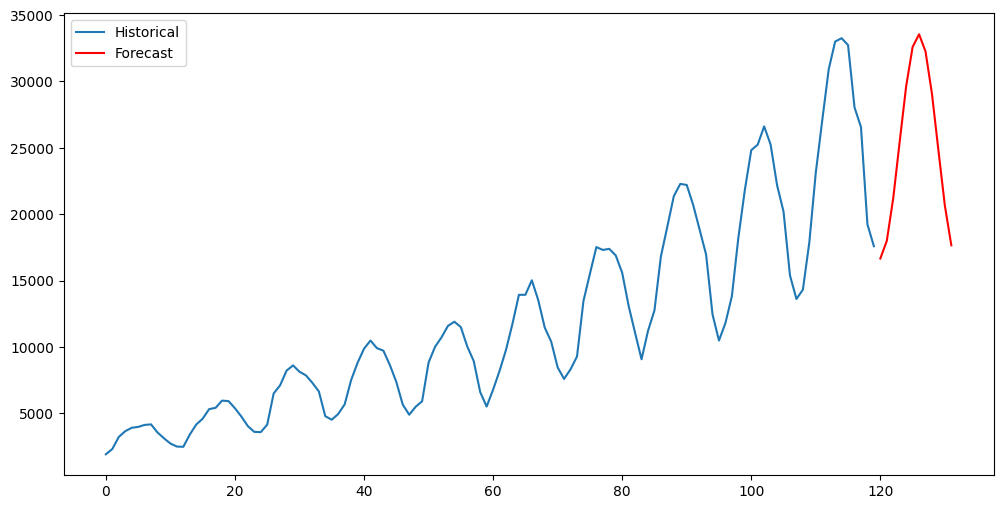

In [63]:
forecast1 = model1_fit.forecast(steps=12)
plt.figure(figsize=(12,6))
plt.plot(df_c['Solar Electricity Net Generation (Megawattshour)'], label='Historical')
plt.plot(forecast1, label='Forecast', color='red')
plt.legend()
plt.show()

In [65]:
from pmdarima import auto_arima

stepwise_model = auto_arima(df_c['Solar Electricity Net Generation (Megawattshour)'], start_p=0, start_q=0,
                            max_p=5, max_q=5, d=None, seasonal=False,
                            trace=True, error_action='ignore', suppress_warnings=True)
print(stepwise_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2141.117, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2077.805, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2103.853, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2139.680, Time=0.00 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2079.474, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2079.745, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2076.302, Time=0.09 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1993.113, Time=0.34 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2036.319, Time=0.14 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=1981.490, Time=0.41 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=2007.400, Time=0.07 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=1981.673, Time=0.48 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=1980.998, Time=0.45 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1974.475, Time=0.37 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept

In [67]:
model2 = ARIMA(df_c['Solar Electricity Net Generation (Megawattshour)'], order=(3,1,2))
model2_fit = model2.fit()
print(model2_fit.summary())

                                              SARIMAX Results                                               
Dep. Variable:     Solar Electricity Net Generation (Megawattshour)   No. Observations:                  120
Model:                                               ARIMA(3, 1, 2)   Log Likelihood                -984.360
Date:                                              Sun, 15 Mar 2026   AIC                           1980.721
Time:                                                      00:32:17   BIC                           1997.396
Sample:                                                           0   HQIC                          1987.492
                                                              - 120                                         
Covariance Type:                                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


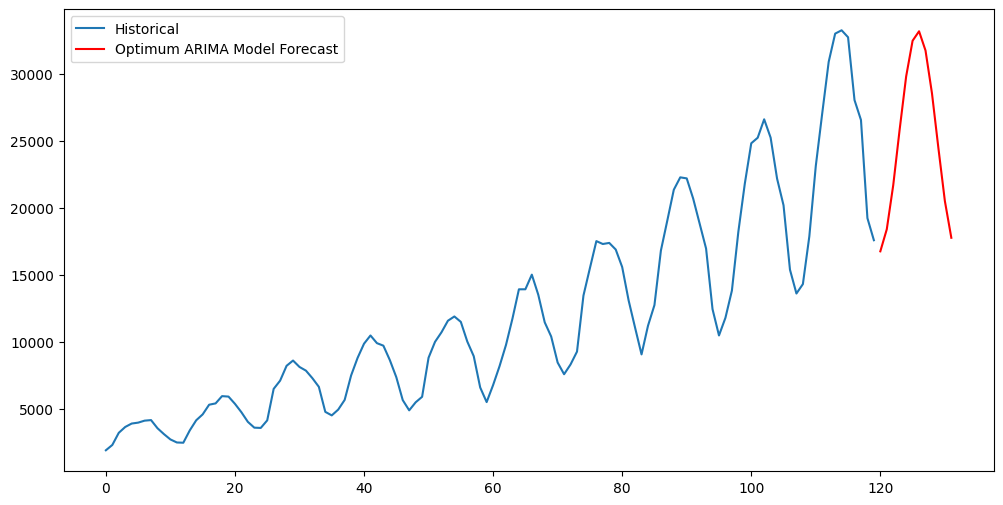

In [68]:
forecast2 = model2_fit.forecast(steps=12)
plt.figure(figsize=(12,6))
plt.plot(df_c['Solar Electricity Net Generation (Megawattshour)'], label='Historical')
plt.plot(forecast2, label='Optimum ARIMA Model Forecast', color='red')
plt.legend()
plt.show()

In [69]:
# Forecast the same number of steps as your test set
n = 12  # or however many months you're forecasting
forecast2 = model2_fit.forecast(steps=n)

# Create actual vs predicted comparison
actual = df_c['Solar Electricity Net Generation (Megawattshour)'][-n:]  # last n months of actual data
predicted = forecast2

In [70]:
# Bias
bias = np.mean(predicted.values - actual.values)
relative_bias = bias / np.mean(actual)

# MAE
mae = mean_absolute_error(actual, predicted)
relative_mae = mae / np.mean(actual)

# MAPE
mape = mean_absolute_percentage_error(actual, predicted)

# MSE
mse = mean_squared_error(actual, predicted)
relative_mse = mse / np.mean(actual ** 2)

# RMSE
rmse = np.sqrt(mse)
relative_rmse = rmse / np.mean(actual)

#Akaike Information Criterion
aic_value = model2_fit.aic

# Print results
print(f"Bias: {bias:.2f}")
print(f"Relative Bias: {relative_bias:.2%}")

print(f"\nMAE: {mae:.2f}")
print(f"Relative MAE: {relative_mae:.2%}")

print(f"\nMAPE: {mape:.2f}%")

print(f"\nMSE: {mse:.2f}")
print(f"Relative MSE: {relative_mse:.2%}")


print(f"\nRMSE: {rmse:.2f}")
print(f"Relative RMSE: {relative_rmse:.2%}")

print(f"\nAIC: {aic_value:.2f}")

Bias: -206.68
Relative Bias: -0.82%

MAE: 1030.88
Relative MAE: 4.07%

MAPE: 0.05%

MSE: 1549307.76
Relative MSE: 0.23%

RMSE: 1244.71
Relative RMSE: 4.92%

AIC: 1980.72


Prediction with SARIMAX for next 12 months

In [71]:
# Non-seasonal order fixed (based on prior ARIMA tuning)
order = (3,1,2)
seasonal_period = 12  # Monthly data with yearly seasonality

train = df_c['Solar Electricity Net Generation (Megawattshour)'][:-12]
test = df_c['Solar Electricity Net Generation (Megawattshour)'][-12:]

best_aic = float('inf')
best_seasonal_order = None
best_model = None

for P in range(3):
    for D in range(2):
        for Q in range(3):
            try:
                model4 = SARIMAX(train,
                                order=order,
                                seasonal_order=(P, D, Q, seasonal_period),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                results = model4.fit()
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_seasonal_order = (P, D, Q, seasonal_period)
                    best_model = results
                print(f"SARIMA{order}x{(P,D,Q,seasonal_period)} - AIC: {results.aic:.2f}")
            except Exception as e:
                print(f"Failed SARIMA{order}x{(P,D,Q,seasonal_period)}: {e}")
                continue

# STEP 4: Report best model
print(f"\n✅ Best SARIMA order: {order}x{best_seasonal_order} with AIC: {best_aic:.2f}")
print(best_model.summary())

SARIMA(3, 1, 2)x(0, 0, 0, 12) - AIC: 1695.58
SARIMA(3, 1, 2)x(0, 0, 1, 12) - AIC: 1498.77
SARIMA(3, 1, 2)x(0, 0, 2, 12) - AIC: 1305.65
SARIMA(3, 1, 2)x(0, 1, 0, 12) - AIC: 1480.28


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(0, 1, 1, 12) - AIC: 1272.67


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(0, 1, 2, 12) - AIC: 2936.67


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(1, 0, 0, 12) - AIC: 1484.50


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(1, 0, 1, 12) - AIC: 1457.63


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(1, 0, 2, 12) - AIC: 1291.70
SARIMA(3, 1, 2)x(1, 1, 0, 12) - AIC: 1293.81


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(1, 1, 1, 12) - AIC: 1295.32


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(1, 1, 2, 12) - AIC: 2996.03


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(2, 0, 0, 12) - AIC: 1264.63


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(2, 0, 1, 12) - AIC: 1290.48


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(2, 0, 2, 12) - AIC: 1286.10
SARIMA(3, 1, 2)x(2, 1, 0, 12) - AIC: 1108.88


C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3, 1, 2)x(2, 1, 1, 12) - AIC: 1098.86
SARIMA(3, 1, 2)x(2, 1, 2, 12) - AIC: 2922.57

✅ Best SARIMA order: (3, 1, 2)x(2, 1, 1, 12) with AIC: 1098.86
                                              SARIMAX Results                                               
Dep. Variable:     Solar Electricity Net Generation (Megawattshour)   No. Observations:                  108
Model:                             SARIMAX(3, 1, 2)x(2, 1, [1], 12)   Log Likelihood                -540.432
Date:                                              Sun, 15 Mar 2026   AIC                           1098.865
Time:                                                      00:38:51   BIC                           1118.840
Sample:                                                           0   HQIC                          1106.780
                                                              - 108                                         
Covariance Type:                                                opg                

✅ Best SARIMA order: (3, 1, 2)x(2, 1, 1, 12) with AIC: 1098.86

In [72]:
model4 = SARIMAX(df_c['Solar Electricity Net Generation (Megawattshour)'], order=(2,1,2), seasonal_order=(2, 1, 2, 12))
model4_fit = model4.fit()
print(model4_fit.summary())

C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


                                              SARIMAX Results                                               
Dep. Variable:     Solar Electricity Net Generation (Megawattshour)   No. Observations:                  120
Model:                               SARIMAX(2, 1, 2)x(2, 1, 2, 12)   Log Likelihood                -854.287
Date:                                              Sun, 15 Mar 2026   AIC                           1726.574
Time:                                                      00:40:21   BIC                           1750.630
Sample:                                                           0   HQIC                          1736.326
                                                              - 120                                         
Covariance Type:                                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

C:\Users\vivir\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


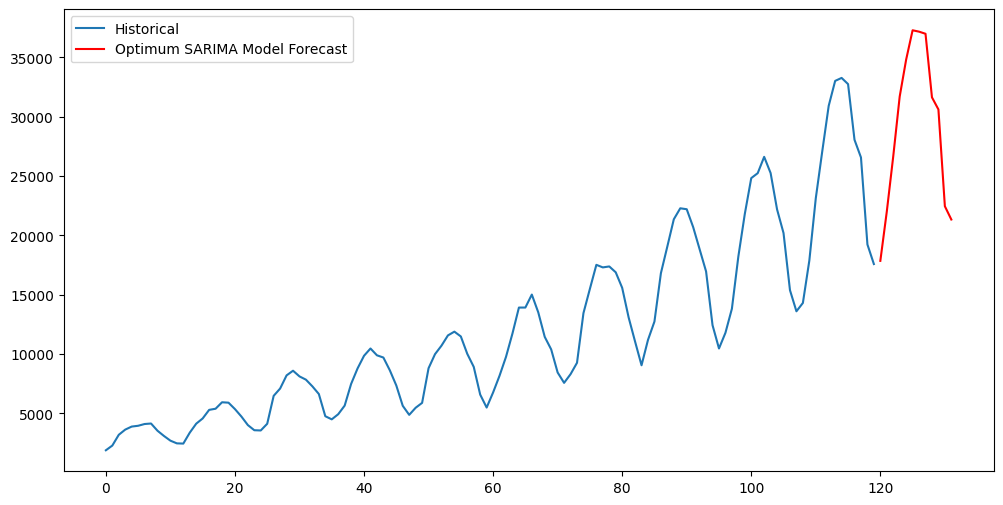

In [73]:
forecast4 = model4_fit.forecast(steps=12)
plt.figure(figsize=(12,6))
plt.plot(df_c['Solar Electricity Net Generation (Megawattshour)'], label='Historical')
plt.plot(forecast4, label='Optimum SARIMA Model Forecast', color='red')
plt.legend()
plt.show()